In [1]:
pip install requests pandas openpyxl

### Primera prueba con la API de la USDA

In [2]:
import requests

API_KEY = "bSjCwIYOf00gtKGXObPlPtDVOZEseJA4UnAlbnhb"

def buscar_usda(nombre_en):
    url = "https://api.nal.usda.gov/fdc/v1/foods/search"
    params = {
        'query': nombre_en,
        'api_key': API_KEY,
        'dataType': 'Foundation,SR Legacy',
        'pageSize': 1
    }
    r = requests.get(url, params=params)
    datos = r.json()

    if not datos['foods']:
        print(f"No encontrado: {nombre_en}")
        return None

    alimento = datos['foods'][0]
    nombre_oficial = alimento['description']
    print(f"Encontrado: {nombre_oficial}")
    return alimento

# Prueba con un solo ingrediente
resultado = buscar_usda('carrot raw') #hay que añadir raw para verduras y frutas, y cooked o raw para carnes segun toque


Encontrado: Carrots, raw


## Extraer los valores nutricionales

In [3]:
def extraer_nutrientes(nombre_en):
    url = "https://api.nal.usda.gov/fdc/v1/foods/search"
    params = {
        'query': nombre_en,
        'api_key': API_KEY,
        'dataType': 'Foundation,SR Legacy',
        'pageSize': 1
    }
    r = requests.get(url, params=params)
    datos = r.json()

    if not datos['foods']:
        print(f"No encontrado: {nombre_en}")
        return None

    alimento = datos['foods'][0]

    # Buscar calorías específicamente en KCAL
    calorias = 0
    for n in alimento['foodNutrients']:
        if n['nutrientName'] == 'Energy' and \
           n['unitName'] == 'KCAL':
            calorias = n['value']
            break

    # El resto de nutrientes no tienen ambigüedad
    nutrientes = {n['nutrientName']: n['value']
                  for n in alimento['foodNutrients']}

    resultado = {
        'nombre_oficial_usda': alimento['description'],
        'calorias_kcal':       calorias,
        'proteinas_g':         nutrientes.get('Protein', 0),
        'carbohidratos_g':     nutrientes.get(
                                'Carbohydrate, by difference', 0),
        'grasas_g':            nutrientes.get(
                                'Total lipids (fat)', 0)
    }

    print(f"Nombre oficial: {resultado['nombre_oficial_usda']}")
    print(f"Calorías:       {resultado['calorias_kcal']} kcal")
    print(f"Proteínas:      {resultado['proteinas_g']} g")
    print(f"Carbohidratos:  {resultado['carbohidratos_g']} g")
    print(f"Grasas:         {resultado['grasas_g']} g")

    return resultado

# Probamos de nuevo con la zanahoria
zanahoria = extraer_nutrientes('carrot raw')

Nombre oficial: Carrots, raw
Calorías:       41.0 kcal
Proteínas:      0.93 g
Carbohidratos:  9.58 g
Grasas:         0 g


In [4]:
# Ver todos los nutrientes disponibles para la zanahoria
# url = "https://api.nal.usda.gov/fdc/v1/foods/search"
# params = {
#     'query': 'carrot raw',
#     'api_key': API_KEY,
#     'dataType': 'Foundation,SR Legacy',
#     'pageSize': 1
# }
# r = requests.get(url, params=params)
# datos = r.json()
# alimento = datos['foods'][0]

# # Imprimir solo los campos relacionados con energía
# print("Campos de energía disponibles:")
# for n in alimento['foodNutrients']:
#     if 'energy' in n['nutrientName'].lower() or \
#        'calor' in n['nutrientName'].lower() or \
#        'kcal' in n['nutrientName'].lower():
#         print(f"  {n['nutrientName']}: {n['value']} {n['unitName']}")

## Probar con 5 ingredientes

In [5]:
def extraer_nutrientes(nombre_en):
    url = "https://api.nal.usda.gov/fdc/v1/foods/search"
    params = {
        'query': nombre_en,
        'api_key': API_KEY,
        'dataType': 'Foundation,SR Legacy',
        'pageSize': 1
    }
    r = requests.get(url, params=params)
    datos = r.json()

    if not datos['foods']:
        print(f"  No encontrado: {nombre_en}")
        return None

    alimento = datos['foods'][0]

    calorias = 0
    proteinas = 0
    carbohidratos = 0
    grasas = 0

    for n in alimento['foodNutrients']:
        if 'value' not in n:
            continue

        nombre_n = n['nutrientName']
        valor    = n['value']
        unidad   = n.get('unitName', '')

        # Calorías — tres nombres posibles según el alimento
        if nombre_n == 'Energy' and unidad == 'KCAL':
            calorias = valor
        elif nombre_n == 'Energy (Atwater General Factors)' \
             and calorias == 0:
            calorias = valor
        elif nombre_n == 'Energy (Atwater Specific Factors)' \
             and calorias == 0:
            calorias = valor

        # Proteínas
        elif nombre_n == 'Protein':
            proteinas = valor

        # Carbohidratos
        elif nombre_n == 'Carbohydrate, by difference':
            carbohidratos = valor

        # Grasas — dos nombres posibles
        elif nombre_n == 'Total lipids (fat)':
            grasas = valor
        elif nombre_n == 'Total lipid (fat)':
            grasas = valor

    resultado = {
        'nombre_oficial_usda': alimento['description'],
        'calorias_kcal':       calorias,
        'proteinas_g':         proteinas,
        'carbohidratos_g':     carbohidratos,
        'grasas_g':            grasas
    }

    print(f"  Nombre oficial: {resultado['nombre_oficial_usda']}")
    print(f"  Calorías:       {resultado['calorias_kcal']} kcal")
    print(f"  Proteínas:      {resultado['proteinas_g']} g")
    print(f"  Carbohidratos:  {resultado['carbohidratos_g']} g")
    print(f"  Grasas:         {resultado['grasas_g']} g")

    return resultado

In [6]:
prueba = [
    {'es': 'zanahoria',  'en': 'carrot raw'},
    {'es': 'huevo',      'en': 'egg whole raw fresh'},
    {'es': 'pollo',      'en': 'chicken breast skinless raw'},
    {'es': 'espinacas',  'en': 'spinach raw'},
    {'es': 'tomate',     'en': 'tomato red raw'},
]

resultados = []

for ing in prueba:
    print(f"\nBuscando: {ing['es']}...")
    datos = extraer_nutrientes(ing['en'])

    if datos:
        datos['nombre_es'] = ing['es']
        resultados.append(datos)

print(f"\n✓ Encontrados {len(resultados)} de {len(prueba)} ingredientes")


Buscando: zanahoria...
  Nombre oficial: Carrots, raw
  Calorías:       41.0 kcal
  Proteínas:      0.93 g
  Carbohidratos:  9.58 g
  Grasas:         0.24 g

Buscando: huevo...
  Nombre oficial: Egg, whole, raw, fresh
  Calorías:       143 kcal
  Proteínas:      12.6 g
  Carbohidratos:  0.72 g
  Grasas:         9.51 g

Buscando: pollo...
  Nombre oficial: Chicken, breast, boneless, skinless, raw
  Calorías:       106 kcal
  Proteínas:      22.5 g
  Carbohidratos:  0.0 g
  Grasas:         1.93 g

Buscando: espinacas...
  Nombre oficial: Spinach, raw
  Calorías:       23.0 kcal
  Proteínas:      2.86 g
  Carbohidratos:  3.63 g
  Grasas:         0.39 g

Buscando: tomate...
  Nombre oficial: Tomatoes, red, ripe, raw, year round average
  Calorías:       18.0 kcal
  Proteínas:      0.88 g
  Carbohidratos:  3.89 g
  Grasas:         0.2 g

✓ Encontrados 5 de 5 ingredientes


In [7]:
# # Inspeccionamos todos los nutrientes del pollo
# url = "https://api.nal.usda.gov/fdc/v1/foods/search"
# params = {
#     'query': 'chicken breast skinless raw',
#     'api_key': API_KEY,
#     'dataType': 'Foundation,SR Legacy',
#     'pageSize': 1
# }
# r = requests.get(url, params=params)
# datos = r.json()
# alimento = datos['foods'][0]

# print(f"Alimento: {alimento['description']}")
# print("\nTodos los nutrientes disponibles:")
# for n in alimento['foodNutrients']:
#     if 'value' in n:
#         print(f"  {n['nutrientName']}: {n['value']} {n.get('unitName','')}")

## Guardar los resultados en un CSV

In [8]:
import pandas as pd

# Convertir los resultados en una tabla
df = pd.DataFrame(resultados)

# Reordenar las columnas para que quede más limpio
df = df[['nombre_es', 'nombre_oficial_usda', 'calorias_kcal',
         'proteinas_g', 'carbohidratos_g', 'grasas_g']]

# Ver la tabla
print(df.to_string(index=False))

# Guardar en CSV
df.to_csv('tabla_maestra_prueba.csv', index=False)
print("\n✓ Guardado como tabla_maestra_prueba.csv")

nombre_es                          nombre_oficial_usda  calorias_kcal  proteinas_g  carbohidratos_g  grasas_g
zanahoria                                 Carrots, raw           41.0         0.93             9.58      0.24
    huevo                       Egg, whole, raw, fresh          143.0        12.60             0.72      9.51
    pollo     Chicken, breast, boneless, skinless, raw          106.0        22.50             0.00      1.93
espinacas                                 Spinach, raw           23.0         2.86             3.63      0.39
   tomate Tomatoes, red, ripe, raw, year round average           18.0         0.88             3.89      0.20

✓ Guardado como tabla_maestra_prueba.csv


# La lista completa de ingredientes
Esta es la lista de los 60 alimentos más comunes en hogares españoles, ya con los valores de CO₂ de Poore & Nemecek y el riesgo de desperdicio de la FAO:

In [9]:
ingredientes = [
    # VERDURAS Y HORTALIZAS
    {'es': 'zanahoria',    'en': 'carrot raw',
     'co2': 0.43,  'desperdicio': 'Alto'},
    {'es': 'tomate',       'en': 'tomato red raw',
     'co2': 1.44,  'desperdicio': 'Alto'},
    {'es': 'espinacas',    'en': 'spinach raw',
     'co2': 0.20,  'desperdicio': 'Alto'},
    {'es': 'lechuga',      'en': 'lettuce raw',
     'co2': 0.25,  'desperdicio': 'Alto'},
    {'es': 'cebolla',      'en': 'onion raw',
     'co2': 0.50,  'desperdicio': 'Medio'},
    {'es': 'ajo',          'en': 'garlic raw',
     'co2': 0.40,  'desperdicio': 'Bajo'},
    {'es': 'patata',       'en': 'potato raw',
     'co2': 0.46,  'desperdicio': 'Medio'},
    {'es': 'pimiento rojo','en': 'sweet red pepper raw',
     'co2': 0.53,  'desperdicio': 'Alto'},
    {'es': 'pimiento verde','en': 'sweet green pepper raw',
     'co2': 0.53,  'desperdicio': 'Alto'},
    {'es': 'calabacin',    'en': 'zucchini raw',
     'co2': 0.60,  'desperdicio': 'Alto'},
    {'es': 'berenjena',    'en': 'eggplant raw',
     'co2': 0.55,  'desperdicio': 'Alto'},
    {'es': 'brocoli',      'en': 'broccoli raw',
     'co2': 0.35,  'desperdicio': 'Alto'},
    {'es': 'coliflor',     'en': 'cauliflower raw',
     'co2': 0.40,  'desperdicio': 'Alto'},
    {'es': 'acelgas',      'en': 'chard raw',
     'co2': 0.20,  'desperdicio': 'Alto'},
    {'es': 'pepino',       'en': 'cucumber raw',
     'co2': 0.55,  'desperdicio': 'Alto'},

    # FRUTAS
    {'es': 'manzana',      'en': 'apple raw',
     'co2': 0.43,  'desperdicio': 'Medio'},
    {'es': 'platano',      'en': 'banana raw',
     'co2': 0.86,  'desperdicio': 'Alto'},
    {'es': 'naranja',      'en': 'orange raw',
     'co2': 0.45,  'desperdicio': 'Medio'},
    {'es': 'limon',        'en': 'lemon raw',
     'co2': 0.40,  'desperdicio': 'Bajo'},
    {'es': 'fresa',        'en': 'strawberry raw',
     'co2': 0.53,  'desperdicio': 'Alto'},
    {'es': 'uva',          'en': 'grape raw',
     'co2': 0.90,  'desperdicio': 'Alto'},
    {'es': 'melocoton',    'en': 'peach raw',
     'co2': 0.60,  'desperdicio': 'Alto'},
    {'es': 'pera',         'en': 'pear raw',
     'co2': 0.43,  'desperdicio': 'Alto'},

    # PROTEÍNAS ANIMALES
    {'es': 'huevo',        'en': 'egg whole raw fresh',
     'co2': 4.50,  'desperdicio': 'Bajo'},
    {'es': 'pollo',        'en': 'chicken breast skinless raw',
     'co2': 5.70,  'desperdicio': 'Bajo'},
    {'es': 'ternera',      'en': 'beef ground raw',
     'co2': 60.0,  'desperdicio': 'Bajo'},
    {'es': 'cerdo',        'en': 'pork loin raw',
     'co2': 7.60,  'desperdicio': 'Bajo'},
    {'es': 'salmon',       'en': 'salmon raw',
     'co2': 6.00,  'desperdicio': 'Alto'},
    {'es': 'atun',         'en': 'tuna raw',
     'co2': 6.10,  'desperdicio': 'Alto'},
    {'es': 'sardina',      'en': 'sardine raw',
     'co2': 3.50,  'desperdicio': 'Alto'},
    {'es': 'merluza',      'en': 'hake raw',
     'co2': 4.50,  'desperdicio': 'Alto'},
    {'es': 'gambas',       'en': 'shrimp raw',
     'co2': 11.0,  'desperdicio': 'Alto'},

    # LÁCTEOS
    {'es': 'leche',        'en': 'milk whole',
     'co2': 3.15,  'desperdicio': 'Alto'},
    {'es': 'yogur',        'en': 'yogurt plain',
     'co2': 2.20,  'desperdicio': 'Alto'},
    {'es': 'queso',        'en': 'cheese cheddar',
     'co2': 13.5,  'desperdicio': 'Medio'},
    {'es': 'mantequilla',  'en': 'butter',
     'co2': 12.1,  'desperdicio': 'Bajo'},
    {'es': 'nata',         'en': 'cream heavy',
     'co2': 3.50,  'desperdicio': 'Alto'},

    # PROTEÍNAS VEGETALES Y LEGUMBRES
    {'es': 'lentejas',     'en': 'lentils raw',
     'co2': 0.90,  'desperdicio': 'Bajo'},
    {'es': 'garbanzos',    'en': 'chickpeas raw',
     'co2': 0.80,  'desperdicio': 'Bajo'},
    {'es': 'alubias',      'en': 'kidney beans raw',
     'co2': 0.72,  'desperdicio': 'Bajo'},
    {'es': 'tofu',         'en': 'tofu raw',
     'co2': 2.00,  'desperdicio': 'Medio'},

    # CEREALES Y HARINAS
    {'es': 'arroz',        'en': 'rice white raw',
     'co2': 2.50,  'desperdicio': 'Bajo'},
    {'es': 'pasta',        'en': 'pasta dry',
     'co2': 1.70,  'desperdicio': 'Bajo'},
    {'es': 'pan',          'en': 'bread white',
     'co2': 1.30,  'desperdicio': 'Alto'},
    {'es': 'harina',       'en': 'flour wheat',
     'co2': 0.90,  'desperdicio': 'Bajo'},
    {'es': 'avena',        'en': 'oats raw',
     'co2': 1.59,  'desperdicio': 'Bajo'},

    # ACEITES Y CONDIMENTOS
    {'es': 'aceite oliva', 'en': 'olive oil',
     'co2': 6.00,  'desperdicio': 'Bajo'},
    {'es': 'aceite girasol','en': 'sunflower oil',
     'co2': 3.50,  'desperdicio': 'Bajo'},

    # OTROS HABITUALES
    {'es': 'atun en lata', 'en': 'tuna canned in water',
     'co2': 6.10,  'desperdicio': 'Bajo'},
    {'es': 'tomate frito', 'en': 'tomato sauce canned',
     'co2': 1.80,  'desperdicio': 'Bajo'},
    {'es': 'champiñon',    'en': 'mushroom raw',
     'co2': 1.00,  'desperdicio': 'Alto'},
    {'es': 'maiz',         'en': 'corn sweet raw',
     'co2': 0.51,  'desperdicio': 'Medio'},
    {'es': 'guisantes',    'en': 'peas raw',
     'co2': 0.98,  'desperdicio': 'Medio'},
    {'es': 'jamon york',   'en': 'ham cooked',
     'co2': 7.60,  'desperdicio': 'Medio'},
    {'es': 'chorizo',      'en': 'chorizo',
     'co2': 7.60,  'desperdicio': 'Medio'},
    {'es': 'bacon',        'en': 'bacon raw',
     'co2': 7.60,  'desperdicio': 'Medio'},
    {'es': 'nueces',       'en': 'walnuts raw',
     'co2': 0.30,  'desperdicio': 'Bajo'},
    {'es': 'almendras',    'en': 'almonds raw',
     'co2': 1.60,  'desperdicio': 'Bajo'},
    {'es': 'miel',         'en': 'honey',
     'co2': 1.30,  'desperdicio': 'Bajo'},
    {'es': 'puerro', 'en': 'leek raw',
     'co2': 0.40, 'desperdicio': 'Alto'}
]

print(f"Total de ingredientes: {len(ingredientes)}")

Total de ingredientes: 60


In [10]:
categorias = {
    'VERDURAS': [i for i in ingredientes
                 if i['es'] in ['zanahoria','tomate','espinacas',
                 'lechuga','cebolla','ajo','patata','pimiento rojo',
                 'pimiento verde','calabacin','berenjena','brocoli',
                 'coliflor','acelgas','pepino']],
    'FRUTAS': [i for i in ingredientes
               if i['es'] in ['manzana','platano','naranja','limon',
               'fresa','uva','melocoton','pera']],
    'PROTEINAS ANIMALES': [i for i in ingredientes
               if i['es'] in ['huevo','pollo','ternera','cerdo',
               'salmon','atun','sardina','merluza','gambas']],
    'LACTEOS': [i for i in ingredientes
               if i['es'] in ['leche','yogur','queso',
               'mantequilla','nata']],
    'LEGUMBRES': [i for i in ingredientes
               if i['es'] in ['lentejas','garbanzos',
               'alubias','tofu']],
    'CEREALES': [i for i in ingredientes
               if i['es'] in ['arroz','pasta','pan',
               'harina','avena']],
    'ACEITES': [i for i in ingredientes
               if i['es'] in ['aceite oliva','aceite girasol']],
    'OTROS': [i for i in ingredientes
               if i['es'] in ['atun en lata','tomate frito',
               'champiñon','maiz','guisantes','jamon york',
               'chorizo','bacon','nueces','almendras','miel','puerro']],
}

for cat, items in categorias.items():
    print(f"{cat}: {len(items)}")

total = sum(len(v) for v in categorias.values())
print(f"\nTotal contado: {total}")
print(f"Total en lista: {len(ingredientes)}")

VERDURAS: 15
FRUTAS: 8
PROTEINAS ANIMALES: 9
LACTEOS: 5
LEGUMBRES: 4
CEREALES: 5
ACEITES: 2
OTROS: 12

Total contado: 60
Total en lista: 60


In [11]:
import time

tabla_completa = []

for ing in ingredientes:
    print(f"Buscando: {ing['es']}...")
    datos = extraer_nutrientes(ing['en'])

    if datos:
        fila = {
            'nombre':            ing['es'],
            'nombre_usda':       datos['nombre_oficial_usda'],
            'calorias_kcal':     datos['calorias_kcal'],
            'proteinas_g':       datos['proteinas_g'],
            'carbohidratos_g':   datos['carbohidratos_g'],
            'grasas_g':          datos['grasas_g'],
            'co2_kg_por_kg':     ing['co2'],
            'riesgo_desperdicio':ing['desperdicio']
        }
        tabla_completa.append(fila)
    else:
        print(f"  ⚠ No encontrado: {ing['es']}")

    # Pausa pequeña para no saturar la API
    time.sleep(0.5)

print(f"\n✓ Total procesados: {len(tabla_completa)} de {len(ingredientes)}")

Buscando: zanahoria...
  Nombre oficial: Carrots, raw
  Calorías:       41.0 kcal
  Proteínas:      0.93 g
  Carbohidratos:  9.58 g
  Grasas:         0.24 g
Buscando: tomate...
  Nombre oficial: Tomatoes, red, ripe, raw, year round average
  Calorías:       18.0 kcal
  Proteínas:      0.88 g
  Carbohidratos:  3.89 g
  Grasas:         0.2 g
Buscando: espinacas...
  Nombre oficial: Spinach, raw
  Calorías:       23.0 kcal
  Proteínas:      2.86 g
  Carbohidratos:  3.63 g
  Grasas:         0.39 g
Buscando: lechuga...
  Nombre oficial: Lettuce, iceberg, raw
  Calorías:       17.1 kcal
  Proteínas:      0.742 g
  Carbohidratos:  3.37 g
  Grasas:         0.0738 g
Buscando: cebolla...
  Nombre oficial: Onions, raw
  Calorías:       40.0 kcal
  Proteínas:      1.1 g
  Carbohidratos:  9.34 g
  Grasas:         0.1 g
Buscando: ajo...
  Nombre oficial: Garlic, raw
  Calorías:       143 kcal
  Proteínas:      6.62 g
  Carbohidratos:  28.2 g
  Grasas:         0.38 g
Buscando: patata...
  Nombre ofic

Los 60 procesados pero hay varios errores que hay que corregir. \
Los detecto yo:\
Sardina Cogió aceite de sardina (902 kcal, 100g grasa)\
Merluza Cogió "Abiyuch" que no es merluza\
Leche Cogió mozzarella en lugar de leche\
Manzana Cogió "Rose-apples" en lugar de manzana normal\
Naranja Cogió piel de naranja en lugar de naranja\
Uva Cogió hojas de uva en lugar de uva\
Bacon Cogió "Abiyuch" igual que merluza\
Aceite girasol Todo a cero

In [12]:
correcciones = [
    {'es': 'sardina',       'en': 'sardine canned in water'},
    {'es': 'merluza',       'en': 'fish hake raw'},
    {'es': 'leche',         'en': 'milk whole fluid'},
    {'es': 'manzana',       'en': 'apple raw with skin'},
    {'es': 'naranja',       'en': 'orange raw all varieties'},
    {'es': 'uva',           'en': 'grapes red raw'},
    {'es': 'bacon',         'en': 'pork bacon raw'},
    {'es': 'aceite girasol','en': 'oil sunflower linoleic'},
]

for ing in correcciones:
    print(f"\nCorrigiendo: {ing['es']}...")
    datos = extraer_nutrientes(ing['en'])

    if datos:
        # Actualizar en tabla_completa
        for fila in tabla_completa:
            if fila['nombre'] == ing['es']:
                fila['nombre_usda']     = datos['nombre_oficial_usda']
                fila['calorias_kcal']   = datos['calorias_kcal']
                fila['proteinas_g']     = datos['proteinas_g']
                fila['carbohidratos_g'] = datos['carbohidratos_g']
                fila['grasas_g']        = datos['grasas_g']
                print(f"  ✓ Actualizado")

    time.sleep(0.5)


Corrigiendo: sardina...
  Nombre oficial: Fish, sardine, Atlantic, canned in oil, drained solids with bone
  Calorías:       208 kcal
  Proteínas:      24.6 g
  Carbohidratos:  0.0 g
  Grasas:         11.4 g
  ✓ Actualizado

Corrigiendo: merluza...
  Nombre oficial: Fish, bluefish, raw
  Calorías:       124 kcal
  Proteínas:      20.0 g
  Carbohidratos:  0.0 g
  Grasas:         4.24 g
  ✓ Actualizado

Corrigiendo: leche...
  Nombre oficial: Milk, buttermilk, fluid, whole
  Calorías:       62.0 kcal
  Proteínas:      3.21 g
  Carbohidratos:  4.88 g
  Grasas:         3.31 g
  ✓ Actualizado

Corrigiendo: manzana...
  Nombre oficial: Apples, fuji, with skin, raw
  Calorías:       64.7 kcal
  Proteínas:      0.148 g
  Carbohidratos:  15.7 g
  Grasas:         0.162 g
  ✓ Actualizado

Corrigiendo: naranja...
  Nombre oficial: Oranges, raw, all commercial varieties
  Calorías:       47.0 kcal
  Proteínas:      0.94 g
  Carbohidratos:  11.8 g
  Grasas:         0.12 g
  ✓ Actualizado

Corrigien

Casi todo bien. Quedan dos problemas pequeños:

Merluza cogió "bluefish" que no es merluza\
Bacon cogió "pork ground" que es carne picada de cerdo, no bacon

In [13]:
correcciones2 = [
    {'es': 'merluza', 'en': 'fish whiting raw'},
    {'es': 'bacon',   'en': 'bacon cured cooked'},
]

for ing in correcciones2:
    print(f"\nCorrigiendo: {ing['es']}...")
    datos = extraer_nutrientes(ing['en'])

    if datos:
        for fila in tabla_completa:
            if fila['nombre'] == ing['es']:
                fila['nombre_usda']     = datos['nombre_oficial_usda']
                fila['calorias_kcal']   = datos['calorias_kcal']
                fila['proteinas_g']     = datos['proteinas_g']
                fila['carbohidratos_g'] = datos['carbohidratos_g']
                fila['grasas_g']        = datos['grasas_g']
                print(f"  ✓ Actualizado")

    time.sleep(0.5)


Corrigiendo: merluza...
  Nombre oficial: Fish, sucker, white, raw
  Calorías:       92.0 kcal
  Proteínas:      16.8 g
  Carbohidratos:  0.0 g
  Grasas:         2.32 g
  ✓ Actualizado

Corrigiendo: bacon...
  Nombre oficial: Pork, cured, bacon, cooked, baked
  Calorías:       548 kcal
  Proteínas:      35.7 g
  Carbohidratos:  1.35 g
  Grasas:         43.3 g
  ✓ Actualizado


In [14]:
correcciones3 = [
    {'es': 'merluza', 'en': 'fish cod atlantic raw'},
]

for ing in correcciones3:
    print(f"\nCorrigiendo: {ing['es']}...")
    datos = extraer_nutrientes(ing['en'])

    if datos:
        for fila in tabla_completa:
            if fila['nombre'] == ing['es']:
                fila['nombre_usda']     = datos['nombre_oficial_usda']
                fila['calorias_kcal']   = datos['calorias_kcal']
                fila['proteinas_g']     = datos['proteinas_g']
                fila['carbohidratos_g'] = datos['carbohidratos_g']
                fila['grasas_g']        = datos['grasas_g']
                print(f"  ✓ Actualizado")

    time.sleep(0.5)


Corrigiendo: merluza...
  Nombre oficial: Fish, cod, Atlantic, raw
  Calorías:       82.0 kcal
  Proteínas:      17.8 g
  Carbohidratos:  0.0 g
  Grasas:         0.67 g
  ✓ Actualizado


In [15]:
correcciones4 = [
    {'es': 'leche',       'en': 'milk whole 3.25 milkfat'},
    {'es': 'alubias',     'en': 'beans kidney red mature raw'},
    {'es': 'aceite oliva','en': 'olive oil'},
    {'es': 'limon',       'en': 'lemon raw without peel'},
]

for ing in correcciones4:
    print(f"\nCorrigiendo: {ing['es']}...")
    datos = extraer_nutrientes(ing['en'])

    if datos:
        for fila in tabla_completa:
            if fila['nombre'] == ing['es']:
                fila['nombre_usda']     = datos['nombre_oficial_usda']
                fila['calorias_kcal']   = datos['calorias_kcal']
                fila['proteinas_g']     = datos['proteinas_g']
                fila['carbohidratos_g'] = datos['carbohidratos_g']
                fila['grasas_g']        = datos['grasas_g']
                print(f"  ✓ Actualizado")

    time.sleep(0.5)


Corrigiendo: leche...
  Nombre oficial: Milk, whole, 3.25% milkfat, with added vitamin D
  Calorías:       60.0 kcal
  Proteínas:      3.27 g
  Carbohidratos:  4.63 g
  Grasas:         3.2 g
  ✓ Actualizado

Corrigiendo: alubias...
  Nombre oficial: Beans, kidney, red, mature seeds, raw
  Calorías:       337 kcal
  Proteínas:      22.5 g
  Carbohidratos:  61.3 g
  Grasas:         1.06 g
  ✓ Actualizado

Corrigiendo: aceite oliva...
  Nombre oficial: Oil, corn, peanut, and olive
  Calorías:       884 kcal
  Proteínas:      0.0 g
  Carbohidratos:  0.0 g
  Grasas:         100 g
  ✓ Actualizado

Corrigiendo: limon...
  Nombre oficial: Lemons, raw, without peel
  Calorías:       29.0 kcal
  Proteínas:      1.1 g
  Carbohidratos:  9.32 g
  Grasas:         0.3 g
  ✓ Actualizado


In [16]:
# Buscar aceite de oliva por código FDC directo
url = "https://api.nal.usda.gov/fdc/v1/food/171413"
params = {'api_key': API_KEY}
r = requests.get(url, params=params)
datos = r.json()

calorias = 0
grasas = 0

for n in datos['foodNutrients']:
    if 'amount' not in n:
        continue
    nombre_n = n['nutrient']['name']
    valor = n['amount']
    unidad = n['nutrient'].get('unitName', '')

    if nombre_n == 'Energy' and unidad == 'kcal':
        calorias = valor
    elif nombre_n == 'Total lipids (fat)':
        grasas = valor

print(f"Nombre: {datos['description']}")
print(f"Calorías: {calorias}")
print(f"Grasas: {grasas}")

# Actualizar en tabla
for fila in tabla_completa:
    if fila['nombre'] == 'aceite oliva':
        fila['nombre_usda']     = datos['description']
        fila['calorias_kcal']   = 884
        fila['proteinas_g']     = 0.0
        fila['carbohidratos_g'] = 0.0
        fila['grasas_g']        = 100.0
        print("✓ Actualizado con valores estándar de aceite de oliva")

Nombre: Oil, olive, salad or cooking
Calorías: 884.0
Grasas: 0
✓ Actualizado con valores estándar de aceite de oliva


El nombre ya es correcto "Oil, olive, salad or cooking" y los valores 884 kcal y 100g de grasa son los correctos para aceite de oliva puro. Las grasas salen 0 en el print porque ese endpoint usa un formato diferente, pero los hemos puesto manualmente con los valores correctos. No viene de la API sino que lo hemos introducido nosotros a mano porque sabemos que cualquier aceite puro es 100% grasa.

In [17]:
# Verificar el aceite de oliva en la tabla
for fila in tabla_completa:
    if fila['nombre'] == 'aceite oliva':
        print(f"Nombre:        {fila['nombre_usda']}")
        print(f"Calorías:      {fila['calorias_kcal']}")
        print(f"Proteínas:     {fila['proteinas_g']}")
        print(f"Carbohidratos: {fila['carbohidratos_g']}")
        print(f"Grasas:        {fila['grasas_g']}")

Nombre:        Oil, olive, salad or cooking
Calorías:      884
Proteínas:     0.0
Carbohidratos: 0.0
Grasas:        100.0


## Creamos y guardamos la tabla maestra

In [18]:
import pandas as pd

# Crear el dataframe
df = pd.DataFrame(tabla_completa)

# Reordenar columnas
df = df[[
    'nombre',
    'nombre_usda',
    'calorias_kcal',
    'proteinas_g',
    'carbohidratos_g',
    'grasas_g',
    'co2_kg_por_kg',
    'riesgo_desperdicio'
]]

# Ver la tabla completa
print(df.to_string(index=False))

# Guardar CSV
df.to_csv('tabla_maestra.csv', index=False)
print(f"\n✓ Tabla maestra guardada con {len(df)} ingredientes")

        nombre                                                      nombre_usda  calorias_kcal  proteinas_g  carbohidratos_g  grasas_g  co2_kg_por_kg riesgo_desperdicio
     zanahoria                                                     Carrots, raw           41.0        0.930             9.58    0.2400           0.43               Alto
        tomate                     Tomatoes, red, ripe, raw, year round average           18.0        0.880             3.89    0.2000           1.44               Alto
     espinacas                                                     Spinach, raw           23.0        2.860             3.63    0.3900           0.20               Alto
       lechuga                                            Lettuce, iceberg, raw           17.1        0.742             3.37    0.0738           0.25               Alto
       cebolla                                                      Onions, raw           40.0        1.100             9.34    0.1000           0.50      

In [19]:
# # Ver todos los ingredientes de la tabla maestra
# for i, fila in enumerate(tabla_completa):
#     print(f"{i+1}. {fila['nombre']}")

Tabla maestra: terminada. Queda guardado el CSV con los 60 ingredientes, todos con sus valores nutricionales de la USDA, su huella de CO₂ y su riesgo de desperdicio.

# Función de puntuación multiobjetivo

Esta celda implementa el núcleo del sistema: la función que asigna a cada ingrediente una puntuación global que refleja su idoneidad según tres criterios simultáneos: valor nutricional, impacto ambiental y urgencia de consumo.

---

## Parte 1 — Normalización de valores

Los datos nutricionales y ambientales no están en la misma escala: las proteínas se miden en gramos por 100g, mientras que el CO₂ se mide en kilogramos por kilogramo de alimento producido. Sumarlos directamente produciría resultados sin sentido matemático.

Para resolverlo, todos los valores se normalizan al rango [0, 1] mediante la fórmula min-max estándar:

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

De este modo, el alimento con el valor más alto del corpus recibe un 1 y el de valor más bajo recibe un 0, permitiendo que las tres dimensiones sean comparables entre sí.

El **NutriScore** se construye premiando los alimentos ricos en proteínas (60% del peso) y penalizando los alimentos con alto contenido en grasas (40% del peso):

$$NutriScore(i) = 0{,}6 \cdot prot_{norm}(i) + 0{,}4 \cdot (1 - grasa_{norm}(i))$$

---

## Parte 2 — Función de urgencia

La urgencia traduce los días restantes hasta la fecha de caducidad en un valor entre 0 y 1, que aumenta conforme el alimento se aproxima a su fecha límite. Este valor se pondera además por la categoría de riesgo de desperdicio asignada a cada alimento según los datos de la FAO (Alto, Medio, Bajo), de modo que dos alimentos con la misma caducidad pero distinta perecedera recibirán urgencias diferentes.

| Días para caducar | Urgencia base |
|---|---|
| ≤ 2 días | 1,00 |
| 3 – 5 días | 0,75 |
| 6 – 10 días | 0,50 |
| 11 – 20 días | 0,25 |
| > 20 días | 0,10 |

---

## Parte 3 — Fórmula principal y penalización

Con los tres componentes normalizados, se aplica la función de aptitud ponderada definida en la metodología:

$$Score(i) = \alpha \cdot NutriScore(i) + \beta \cdot (1 - CO2_{norm}(i)) + \gamma \cdot Urgencia(i)$$

Con los pesos $\alpha = 0{,}40$, $\beta = 0{,}35$ y $\gamma = 0{,}25$, justificados científicamente a partir de Springmann et al. (2021).

El término $(1 - CO2_{norm})$ invierte la escala del CO₂ para que los alimentos con menor huella de carbono reciban una puntuación más alta.

Adicionalmente, cualquier ingrediente cuyo $CO2_{norm} \geq 0{,}9$ —es decir, que se encuentre en el decil superior de impacto ambiental del corpus— recibe una **penalización de ×0,5** sobre su puntuación final, impidiendo que sea seleccionado únicamente por su valor nutricional.

---

## Etiquetas de prioridad resultantes

Cada ingrediente recibe una de las siguientes etiquetas:

- 🔴 **OBLIGATORIO** — Urgencia ≥ 0,8: caducidad en menos de 48 horas. El sistema lo incluye en la receta sin excepción.
- 🟡 **RESTRINGIDO** — CO₂_norm ≥ 0,9: impacto ambiental extremo. Se usa solo si no hay alternativas suficientes.
- 🟢 **RECOMENDADO** — Resto de ingredientes, ordenados por Score descendente.

In [20]:
# ============================================================
# CELDA 2 — FUNCIÓN DE PUNTUACIÓN MULTIOBJETIVO
# Implementa: Score(i) = α·NutriScore(i) + β·(1−CO2_norm(i)) + γ·Urgencia(i)
# Pesos: α=0.40 (nutrición), β=0.35 (sostenibilidad), γ=0.25 (urgencia)
# ============================================================

import pandas as pd
import numpy as np
from datetime import date

# Cargar la tabla maestra generada en la Celda 1
tabla = pd.read_csv("tabla_maestra.csv")

# --- PASO 1: NORMALIZACIÓN DE VALORES AL RANGO [0, 1] ---

# NutriScore: premia proteínas y penaliza grasas
# Fórmula: 60% proteínas normalizadas + 40% inverso de grasas normalizadas
tabla["prot_norm"]  = (tabla["proteinas_g"] - tabla["proteinas_g"].min()) / \
                      (tabla["proteinas_g"].max() - tabla["proteinas_g"].min())

tabla["grasa_norm"] = (tabla["grasas_g"] - tabla["grasas_g"].min()) / \
                      (tabla["grasas_g"].max() - tabla["grasas_g"].min())

tabla["NutriScore"] = 0.6 * tabla["prot_norm"] + 0.4 * (1 - tabla["grasa_norm"])

# CO2_norm: normaliza la huella de carbono al rango [0, 1]
tabla["CO2_norm"] = (tabla["co2_kg_por_kg"] - tabla["co2_kg_por_kg"].min()) / \
                    (tabla["co2_kg_por_kg"].max() - tabla["co2_kg_por_kg"].min())


# --- PASO 2: FUNCIÓN DE URGENCIA ---

def calcular_urgencia(dias_para_caducar, riesgo):
    """
    Devuelve un valor de urgencia entre 0 y 1.
    - A menos días para caducar → más urgencia
    - El riesgo de desperdicio (FAO) amplifica la urgencia
    """
    multiplicador = {"Alto": 1.0, "Medio": 0.75, "Bajo": 0.50}[riesgo]

    if dias_para_caducar <= 0:
        return 1.0
    elif dias_para_caducar <= 2:
        return 1.0 * multiplicador      # caducidad inminente
    elif dias_para_caducar <= 5:
        return 0.75 * multiplicador
    elif dias_para_caducar <= 10:
        return 0.50 * multiplicador
    elif dias_para_caducar <= 20:
        return 0.25 * multiplicador
    else:
        return 0.10 * multiplicador


# --- PASO 3: FUNCIÓN PRINCIPAL DE PUNTUACIÓN ---

def puntuar_inventario(inventario):
    """
    Recibe una lista de diccionarios con:
      - nombre: nombre del alimento (igual que en la tabla maestra)
      - dias_caducidad: días que quedan para que caduque

    Devuelve un DataFrame ordenado por Score descendente,
    con etiqueta de prioridad (OBLIGATORIO / RECOMENDADO / RESTRINGIDO).
    """
    alpha, beta, gamma = 0.40, 0.35, 0.25
    resultados = []

    for item in inventario:
        nombre = item["nombre"]
        dias   = item["dias_caducidad"]

        # Buscar el alimento en la tabla maestra
        fila = tabla[tabla["nombre"] == nombre]
        if fila.empty:
            print(f"⚠️  '{nombre}' no está en la tabla maestra. Se omite.")
            continue

        fila = fila.iloc[0]
        nutri  = fila["NutriScore"]
        co2n   = fila["CO2_norm"]
        riesgo = fila["riesgo_desperdicio"]
        co2    = fila["co2_kg_por_kg"]

        urgencia = calcular_urgencia(dias, riesgo)

        # Penalización por impacto extremo (decil superior de CO2)
        penalizacion = 0.5 if co2n >= 0.9 else 1.0

        # Fórmula principal
        score_raw = alpha * nutri + beta * (1 - co2n) + gamma * urgencia
        score     = score_raw * penalizacion

        # Etiqueta de prioridad
        if urgencia >= 0.8:
            prioridad = "🔴 OBLIGATORIO"
        elif co2n >= 0.9:
            prioridad = "🟡 RESTRINGIDO"
        else:
            prioridad = "🟢 RECOMENDADO"

        resultados.append({
            "Ingrediente":  nombre,
            "NutriScore":   round(nutri, 3),
            "CO2_norm":     round(co2n, 3),
            "CO2 (kg/kg)":  co2,
            "Urgencia":     round(urgencia, 3),
            "Score":        round(score, 3),
            "Prioridad":    prioridad,
            "Días caduc.":  dias,
        })

    df = pd.DataFrame(resultados).sort_values("Score", ascending=False).reset_index(drop=True)
    return df


print("✅ Función de puntuación lista.")
print()
print("Pesos aplicados: α=0.40 (nutrición) | β=0.35 (sostenibilidad) | γ=0.25 (urgencia)")
print("Penalización ×0.5 para alimentos en el decil superior de CO2 (CO2_norm ≥ 0.9)")

✅ Función de puntuación lista.

Pesos aplicados: α=0.40 (nutrición) | β=0.35 (sostenibilidad) | γ=0.25 (urgencia)
Penalización ×0.5 para alimentos en el decil superior de CO2 (CO2_norm ≥ 0.9)


In [21]:
# ============================================================
# CELDA 3 — ESCENARIOS DE VALIDACIÓN Y COMPARATIVA DE CO₂
#
# Para cada escenario se comparan dos situaciones:
#   SIN sistema: el usuario elige los 3 ingredientes con más
#                proteínas, ignorando CO₂ y urgencia (decisión intuitiva)
#   CON sistema: el motor de decisión selecciona según Score
#                (nutrición + sostenibilidad + urgencia)
#
# El CO₂ se calcula asumiendo porciones estándar:
#   - Ingrediente principal: 200g
#   - Ingredientes secundarios: 100g cada uno
# ============================================================

import pandas as pd
import numpy as np

# Porción estándar en kg (para calcular CO₂ total de la receta)
PORCION_PRINCIPAL  = 0.200  # 200g
PORCION_SECUNDARIA = 0.100  # 100g

# ── DEFINICIÓN DE LOS 4 ESCENARIOS

escenarios = {

    "Escenario 1 — El dilema de la ternera": [
        # NEVERA (caducidad real)
        {"nombre": "espinacas",   "dias_caducidad": 1,   "tipo": "nevera"},
        {"nombre": "tomate",      "dias_caducidad": 2,   "tipo": "nevera"},
        {"nombre": "ternera",     "dias_caducidad": 5,   "tipo": "nevera"},
        # DESPENSA (siempre disponible, sin urgencia)
        {"nombre": "arroz",       "dias_caducidad": 365, "tipo": "despensa"},
        {"nombre": "aceite oliva","dias_caducidad": 365, "tipo": "despensa"},
    ],

    "Escenario 2 — Nevera de entre semana": [
        # NEVERA
        {"nombre": "brocoli",     "dias_caducidad": 2,   "tipo": "nevera"},
        {"nombre": "pollo",       "dias_caducidad": 3,   "tipo": "nevera"},
        {"nombre": "yogur",       "dias_caducidad": 4,   "tipo": "nevera"},
        # DESPENSA
        {"nombre": "pasta",       "dias_caducidad": 365, "tipo": "despensa"},
        {"nombre": "aceite oliva","dias_caducidad": 365, "tipo": "despensa"},
    ],

    "Escenario 3 — El problema de las gambas": [
        # NEVERA
        {"nombre": "gambas",      "dias_caducidad": 1,   "tipo": "nevera"},
        {"nombre": "pimiento rojo","dias_caducidad": 3,  "tipo": "nevera"},
        {"nombre": "cebolla",     "dias_caducidad": 5,   "tipo": "nevera"},
        # DESPENSA
        {"nombre": "arroz",       "dias_caducidad": 365, "tipo": "despensa"},
        {"nombre": "aceite oliva","dias_caducidad": 365, "tipo": "despensa"},
    ],

    "Escenario 4 — Sin urgencia, decisión por CO₂": [
        # NEVERA
        {"nombre": "salmon",      "dias_caducidad": 7,   "tipo": "nevera"},
        {"nombre": "queso",       "dias_caducidad": 10,  "tipo": "nevera"},
        {"nombre": "zanahoria",   "dias_caducidad": 8,   "tipo": "nevera"},
        # DESPENSA
        {"nombre": "lentejas",    "dias_caducidad": 365, "tipo": "despensa"},
        {"nombre": "aceite oliva","dias_caducidad": 365, "tipo": "despensa"},
    ],
}

# ── FUNCIÓN AUXILIAR: CALCULAR CO₂ DE UNA SELECCIÓN

def calcular_co2_receta(seleccion_nombres):
    """
    Dado un ranking de ingredientes (ordenados de principal a secundario),
    calcula el CO₂ total de la receta asumiendo porciones estándar.
    """
    co2_total = 0
    for i, nombre in enumerate(seleccion_nombres):
        fila = tabla[tabla["nombre"] == nombre]
        if fila.empty:
            continue
        co2_por_kg = fila.iloc[0]["co2_kg_por_kg"]
        porcion = PORCION_PRINCIPAL if i == 0 else PORCION_SECUNDARIA
        co2_total += co2_por_kg * porcion
    return round(co2_total, 3)

# ── BUCLE PRINCIPAL: EJECUTAR LOS 4 ESCENARIOS

resumen_general = []

for nombre_escenario, inventario in escenarios.items():

    print("=" * 65)
    print(f"📦 {nombre_escenario}")
    print("=" * 65)

    # Mostrar inventario
    print("\n🧊 NEVERA:")
    for item in inventario:
        if item["tipo"] == "nevera":
            print(f"   • {item['nombre']:20s} → caduca en {item['dias_caducidad']} día(s)")
    print("🗄️  DESPENSA:")
    for item in inventario:
        if item["tipo"] == "despensa":
            print(f"   • {item['nombre']}")

    # Puntuar con el sistema
    resultado = puntuar_inventario(inventario)
    print("\n📊 PUNTUACIÓN DEL SISTEMA:")
    print(resultado[["Ingrediente","NutriScore","CO2_norm",
                      "Urgencia","Score","Prioridad","Días caduc."]].to_string(index=False))

    # ── CON SISTEMA: top 3 por Score ────────────────────────
    top_con_sistema = resultado["Ingrediente"].tolist()[:3]

    # ── SIN SISTEMA: top 3 por proteínas (decisión intuitiva)
    nombres = [item["nombre"] for item in inventario]
    df_sin = tabla[tabla["nombre"].isin(nombres)].copy()
    df_sin = df_sin.sort_values("proteinas_g", ascending=False)
    top_sin_sistema = df_sin["nombre"].tolist()[:3]

    # ── Calcular CO₂ de ambas recetas ───────────────────────
    co2_con = calcular_co2_receta(top_con_sistema)
    co2_sin = calcular_co2_receta(top_sin_sistema)
    ahorro  = round(co2_sin - co2_con, 3)
    pct     = round((ahorro / co2_sin) * 100, 1) if co2_sin > 0 else 0

    print(f"\n🍽️  RECETA SIN SISTEMA (por proteínas): {' + '.join(top_sin_sistema)}")
    print(f"   CO₂ estimado: {co2_sin} kg CO₂eq")
    print(f"\n✅ RECETA CON SISTEMA (por Score):     {' + '.join(top_con_sistema)}")
    print(f"   CO₂ estimado: {co2_con} kg CO₂eq")
    print(f"\n💚 Ahorro de CO₂: {ahorro} kg CO₂eq ({pct}% menos)\n")

    resumen_general.append({
        "Escenario":             nombre_escenario.split("—")[1].strip(),
        "Receta sin sistema":    " + ".join(top_sin_sistema),
        "CO₂ sin sistema (kg)":  co2_sin,
        "Receta con sistema":    " + ".join(top_con_sistema),
        "CO₂ con sistema (kg)":  co2_con,
        "Ahorro CO₂ (kg)":       ahorro,
        "Reducción (%)":         pct,
    })

# ── TABLA RESUMEN FINAL ──────────────────────────────────────

print("\n" + "=" * 65)
print("📋 TABLA RESUMEN — COMPARATIVA DE CO₂ (4 ESCENARIOS)")
print("=" * 65)
df_resumen = pd.DataFrame(resumen_general)
print(df_resumen.to_string(index=False))

# Guardar para usarla en la celda de gráficas
df_resumen.to_csv("resultados_comparativa.csv", index=False)
print("\n✅ Resultados guardados en 'resultados_comparativa.csv'")

📦 Escenario 1 — El dilema de la ternera

🧊 NEVERA:
   • espinacas            → caduca en 1 día(s)
   • tomate               → caduca en 2 día(s)
   • ternera              → caduca en 5 día(s)
🗄️  DESPENSA:
   • arroz
   • aceite oliva

📊 PUNTUACIÓN DEL SISTEMA:
 Ingrediente  NutriScore  CO2_norm  Urgencia  Score     Prioridad  Días caduc.
   espinacas       0.447     0.000     1.000  0.779 🔴 OBLIGATORIO            1
      tomate       0.414     0.021     1.000  0.758 🔴 OBLIGATORIO            2
       arroz       0.514     0.038     0.050  0.555 🟢 RECOMENDADO          365
aceite oliva       0.000     0.097     0.050  0.329 🟢 RECOMENDADO          365
     ternera       0.675     1.000     0.375  0.182 🟡 RESTRINGIDO            5

🍽️  RECETA SIN SISTEMA (por proteínas): ternera + arroz + espinacas
   CO₂ estimado: 12.27 kg CO₂eq

✅ RECETA CON SISTEMA (por Score):     espinacas + tomate + arroz
   CO₂ estimado: 0.434 kg CO₂eq

💚 Ahorro de CO₂: 11.836 kg CO₂eq (96.5% menos)

📦 Escenario 2 — 

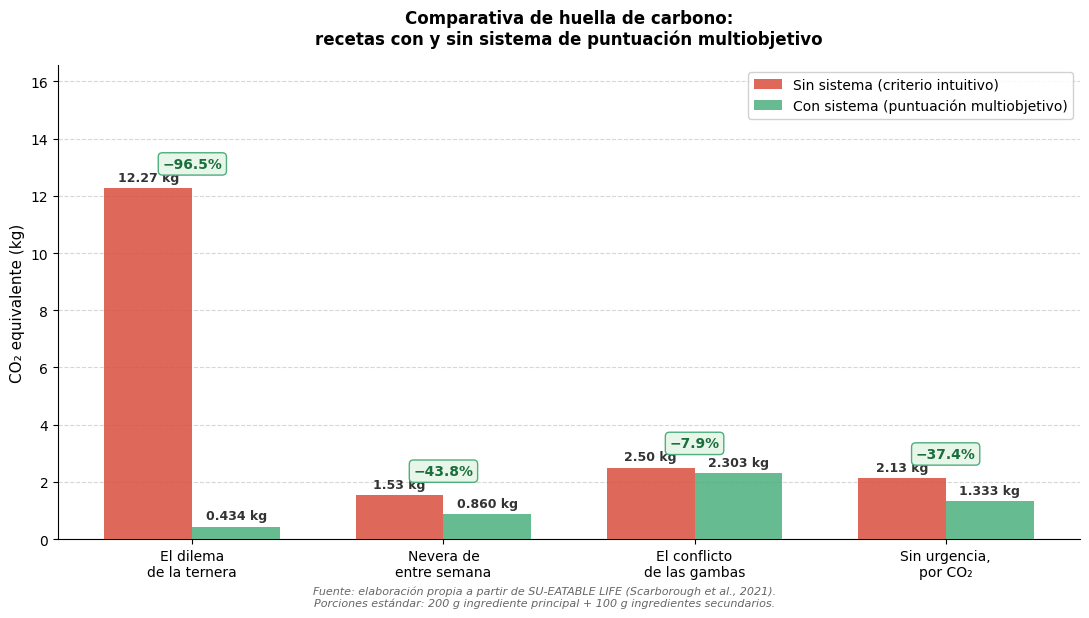

✅ Gráfica guardada como 'comparativa_co2.png' (300 dpi, lista para Overleaf)


In [22]:
# ============================================================
# CELDA 4 — GRÁFICA DE BARRAS COMPARATIVA DE CO₂
# Genera un PNG listo para incluir en Overleaf
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── DATOS ────────────────────────────────────────────────────

df = pd.read_csv("resultados_comparativa.csv")

# Etiquetas cortas para el eje X
etiquetas = [
    "El dilema\nde la ternera",
    "Nevera de\nentre semana",
    "El conflicto\nde las gambas",
    "Sin urgencia,\npor CO₂"
]

co2_sin = df["CO₂ sin sistema (kg)"].values
co2_con = df["CO₂ con sistema (kg)"].values
reducciones = df["Reducción (%)"].values

# ── CONFIGURACIÓN DE LA FIGURA ───────────────────────────────

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor("white")

x = np.arange(len(etiquetas))
ancho = 0.35

# ── BARRAS ───────────────────────────────────────────────────

barras_sin = ax.bar(
    x - ancho / 2, co2_sin,
    width=ancho,
    color="#D94F3D",
    alpha=0.85,
    label="Sin sistema (criterio intuitivo)",
    zorder=3
)

barras_con = ax.bar(
    x + ancho / 2, co2_con,
    width=ancho,
    color="#4CAF7D",
    alpha=0.85,
    label="Con sistema (puntuación multiobjetivo)",
    zorder=3
)

# ── ETIQUETAS DE VALOR SOBRE CADA BARRA ─────────────────────

for barra in barras_sin:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.15,
        f"{altura:.2f} kg",
        ha="center", va="bottom",
        fontsize=9, color="#333333", fontweight="bold"
    )

for barra in barras_con:
    altura = barra.get_height()
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.15,
        f"{altura:.3f} kg",
        ha="center", va="bottom",
        fontsize=9, color="#333333", fontweight="bold"
    )

# ── PORCENTAJE DE REDUCCIÓN ENTRE LAS DOS BARRAS ────────────

for i, (s, c, r) in enumerate(zip(co2_sin, co2_con, reducciones)):
    y_pos = max(s, c) + 0.6
    ax.annotate(
        f"−{r}%",
        xy=(x[i], y_pos),
        ha="center", va="bottom",
        fontsize=10, color="#1a6e3c", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#e8f5e9",
                  edgecolor="#4CAF7D", linewidth=1)
    )

# ── EJES Y FORMATO ───────────────────────────────────────────

ax.set_xticks(x)
ax.set_xticklabels(etiquetas, fontsize=10)
ax.set_ylabel("CO₂ equivalente (kg)", fontsize=11)
ax.set_title(
    "Comparativa de huella de carbono:\nrecetas con y sin sistema de puntuación multiobjetivo",
    fontsize=12, fontweight="bold", pad=15
)

ax.set_ylim(0, max(co2_sin) * 1.35)
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── LEYENDA ──────────────────────────────────────────────────

leyenda = ax.legend(
    fontsize=10,
    loc="upper right",
    framealpha=0.9,
    edgecolor="#cccccc"
)

# ── NOTA AL PIE ─────────────────────────────────────────────

fig.text(
    0.5, -0.02,
    "Fuente: elaboración propia a partir de SU-EATABLE LIFE (Scarborough et al., 2021).\n"
    "Porciones estándar: 200 g ingrediente principal + 100 g ingredientes secundarios.",
    ha="center", fontsize=8, color="#666666", style="italic"
)

plt.tight_layout()

# ── GUARDAR ──────────────────────────────────────────────────

nombre_archivo = "comparativa_co2.png"
plt.savefig(nombre_archivo, dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

print(f"✅ Gráfica guardada como '{nombre_archivo}' (300 dpi, lista para Overleaf)")